In [1]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fontsize = 14
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": fontsize,
    #'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents}',
    'figure.dpi': 200
})

In [3]:
from typing import Dict, Tuple, Optional

def get_last_file(path: Path) -> Path | None:
    # --- Step 1: Look for final files first ---
    final_candidates = [
        path / "TR_IRGNM_final.pkl",
        path / "FOM_IRGNM_final.pkl"
    ]
    
    for final_file in final_candidates:
        if final_file.exists():
            return final_file.name  # Return immediately if found
    
    # --- Step 2: If no final file exists, find the highest index file ---
    files = glob.glob(os.path.join(path, "TR_IRGNM_*.pkl"))
    files += glob.glob(os.path.join(path, "FOM_IRGNM_*.pkl"))

    indexed_files = []
    for f in files:
        match = re.search(r'(?:TR|FOM)_IRGNM_(\d+)\.pkl$', os.path.basename(f))
        if match:
            idx = int(match.group(1))
            indexed_files.append((idx, f))

    if indexed_files:
        _, max_file = max(indexed_files, key=lambda x: x[0])
        return Path(max_file).name

    print("No matching IRGNM result files found.")
    return None

def filter_and_reorder(d: Dict, pattern: str = r'.*FOM.*') -> Tuple[Dict, Optional[str]]:
    regex = re.compile(pattern)
    matching = [k for k in d if regex.search(k)]
    non_matching = [k for k in d if k not in matching]

    # Sort keys alphabetically within each group
    non_matching_sorted = sorted(non_matching)
    matching_sorted = sorted(matching)

    # Build the reordered dict: alphabetically sorted non-matching first, then matching ones
    reordered = {k: d[k] for k in non_matching_sorted}
    reordered.update({k: d[k] for k in matching_sorted})

    # Return reordered dict and the single matching key (if exactly one match)
    if len(matching_sorted) == 1:
        return reordered, matching_sorted[0]
    else:
        return reordered, None

In [10]:
#SAVE_PATH = Path('/home/dealii/workdir/figs')
SAVE_PATH = Path('/home/benedikt/Schreibtisch/error_stagnation')

########################################################################################

# WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
# #WORK_DIR = Path('/home/dealii/workdir/experiments')
# #WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')

# subset = 'new_baseline'
# obs_op = 'sensors'
# data_dir_path = WORK_DIR / 'pre_paper_version' / 'new_baseline'

# experiment_names = []
# pattern = re.compile(rf'^{subset}_.*_{obs_op}.*')

# experiment_names += [
#     d.name for d in data_dir_path.iterdir()
#     if d.is_dir() and pattern.match(d.name)
# ]

# data_paths = [data_dir_path / experiment_name for experiment_name in experiment_names]
# file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

#data_dir_path = Path('/home/dealii/workdir/examples/elasticity/dumps') / '20251201_121655_TR_IRGNM'
data_dir_path = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity/dumps') / '20251201_162724_TR_IRGNM'

experiment_names = []
pattern = re.compile(rf'.*')

experiment_names += [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

data_paths = [data_dir_path]
file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

setup = None
data = {}
optimizer_parameters = {}

for (data_path, file_name) in zip(data_paths, file_names):            

    try:
        with open(data_path / file_name, 'rb') as file:
            data_ = load(file)
        data[str(data_path.name)] = data_
    except TypeError:
        print(f"Can not find dumps for {data_path}")
    except:
        print(f"Can not open {data_path / file_name}")

    if not setup:
        with open(data_path / 'setup.pkl', 'rb') as file:
            setup = load(file)

    
    optimizer_parameter_path = data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
        
    optimizer_parameters[str(data_path.name)] = optimizer_parameter

data, FOM_key = filter_and_reorder(data, pattern=r'.*FOM.*')
#assert FOM_key

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

print(data.keys())


No matching IRGNM result files found.
Can not find dumps for /home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity/dumps/20251201_162724_TR_IRGNM
dict_keys([])


In [5]:
FOM = build_InstationaryModelIP(setup=setup)

[2025-12-01 16:06:47,545][build_InstationaryModelIP] - Construct problem..
	 Setting up BC constraints.
	 Setting up system matrizies.
	 Using CosseratDelamination SystemMatrix
[2025-12-01 16:06:47,670][__init__] - Setting up InstationaryModelIP
	 Using CenterExcite BodyForce
	 Assembling force list.
	 ---------------------- 
	 #DoFs: 1215
	 #Parameter: 81
[2025-12-01 16:06:47,673][reset_cached_operators] - Deleting cache
0.2559323779143406
0.2559323779143406
0.255933473600898
5.533009952066652e-06
5.533009952068957e-06
[2025-12-01 16:06:48,073][build_InstationaryModelIP] - noise percentage is nan
[2025-12-01 16:06:48,074][build_InstationaryModelIP] - noise_level is 5.0000e-05
[2025-12-01 16:06:48,079][__init__] - Setting up InstationaryModelIP
[2025-12-01 16:06:48,080][reset_cached_operators] - Deleting cache


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

[2025-12-01 16:06:48,203][build_InstationaryModelIP] - Construct problem..
	 Setting up BC constraints.
	 Setting up system matrizies.
	 Using CosseratDelamination SystemMatrix
[2025-12-01 16:06:48,319][__init__] - Setting up InstationaryModelIP
	 Using CenterExcite BodyForce
	 Assembling force list.
	 ---------------------- 
	 #DoFs: 1215
	 #Parameter: 81
[2025-12-01 16:06:48,320][reset_cached_operators] - Deleting cache
0.2559323779143406
0.2559323779143406
0.2559359383782328
5.602481951265428e-06
5.6024819512640045e-06
[2025-12-01 16:06:48,711][build_InstationaryModelIP] - noise percentage is nan
[2025-12-01 16:06:48,712][build_InstationaryModelIP] - noise_level is 5.0000e-05
[2025-12-01 16:06:48,718][__init__] - Setting up InstationaryModelIP
[2025-12-01 16:06:48,719][reset_cached_operators] - Deleting cache
[2025-12-01 16:06:48,721][__init__] - Setting up InstationaryModelIPReductor
[2025-12-01 16:06:48,722][__init__] - Using residual image basis mode: 'none'.
[2025-12-01 16:06:48

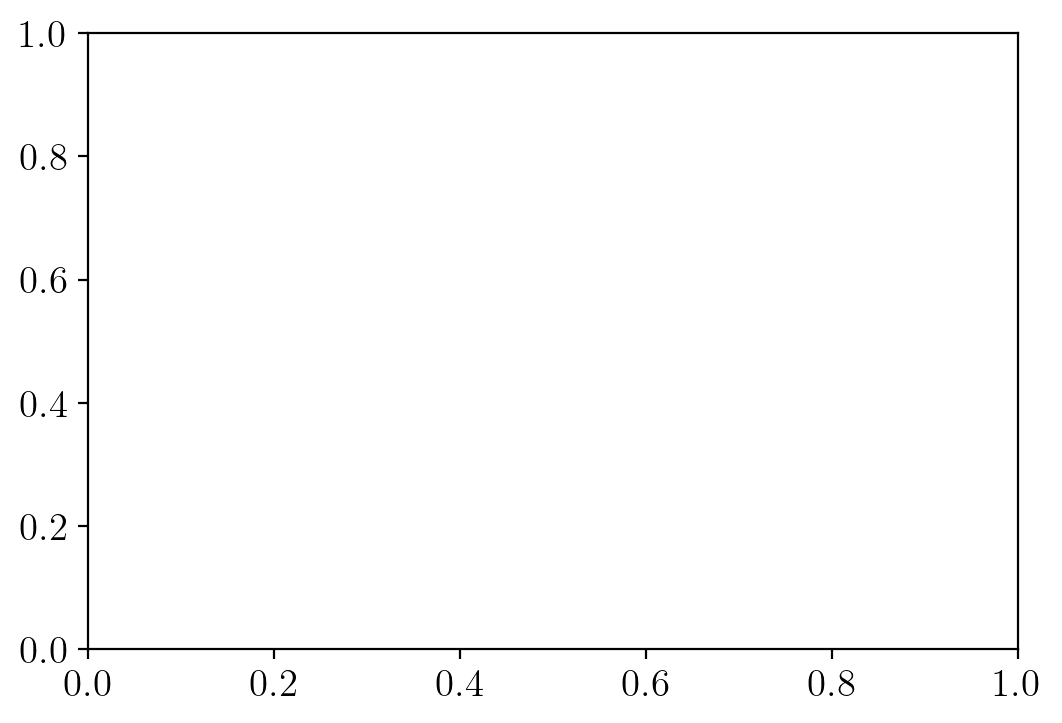

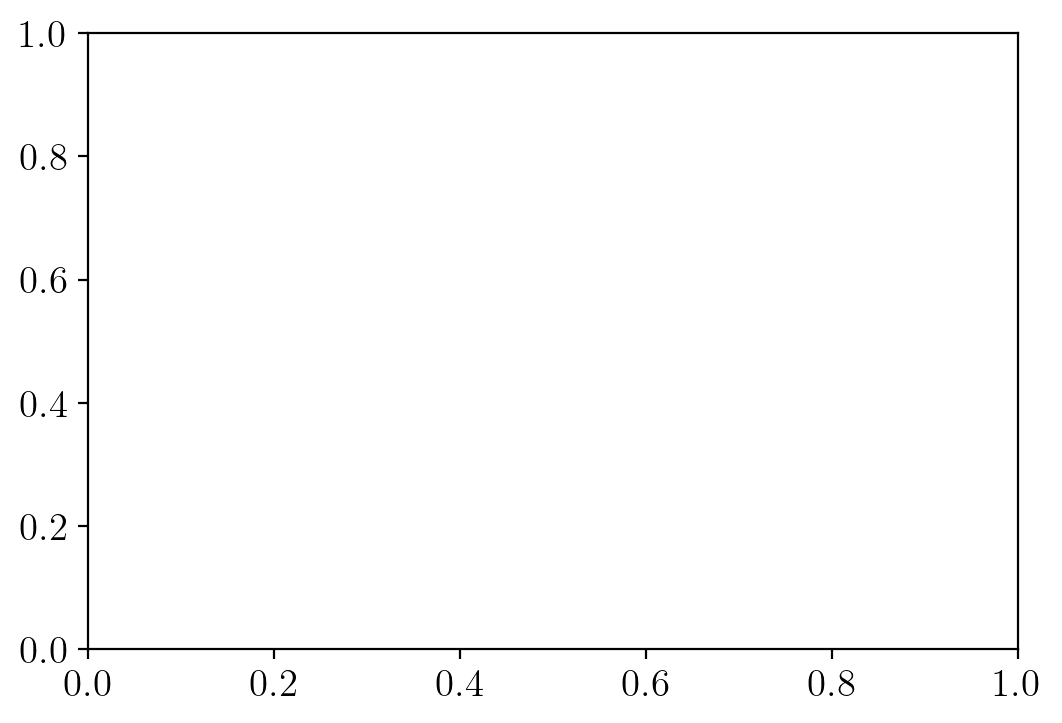

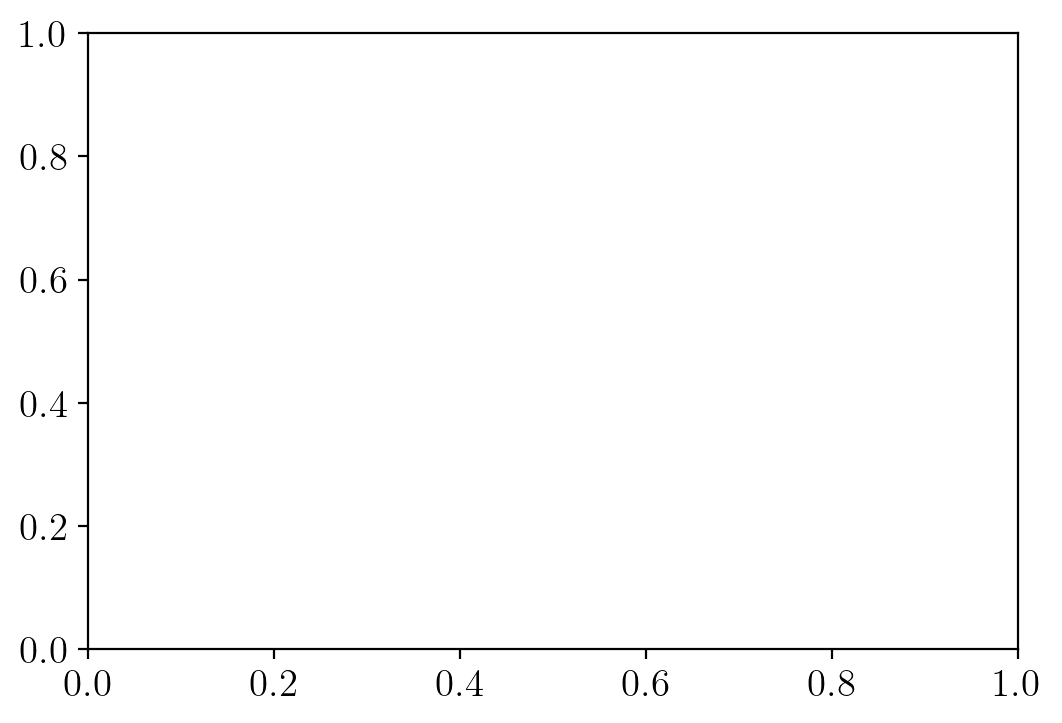

In [6]:
from RBInvParam.reductor import InstationaryModelIPReductor
from RBInvParam.optimizer import QrVrROMOptimizer

FOM = build_InstationaryModelIP(setup=setup)
reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)

optimizer = QrVrROMOptimizer(
        FOM = FOM,
        optimizer_parameter = optimizer_parameter,
        save_path='./'
    )

In [7]:
import pymor_dealii_bindings as pd2

data_ = data['20251201_152544_TR_IRGNM']
bases = ['parameter_basis', 'state_basis']

reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)


for basis in bases:
    snapshots_ = data_['snapshots'][basis].to_numpy()
    if basis == 'parameter_basis':
        snapshots = FOM.Q.make_array(snapshots_)
    else:
        snapshots = FOM.V.empty()
        for i in range(snapshots_.shape[0]):
            snapshots.append(
                FOM.V.make_array([FOM.V.real_vector_from_numpy(snapshots_[i])])
            )
    reductor.extend_basis(
        U = snapshots,
        basis = basis
    )

reductor.dims_history['parameter_basis'].append(reductor.get_bases_dim('parameter_basis'))
reductor.dims_history['state_basis'].append(reductor.get_bases_dim('state_basis'))
reductor.dims_history['adjoint_basis'].append(reductor.get_bases_dim('adjoint_basis'))

print(f"Dim Qr-space = {reductor.get_bases_dim('parameter_basis')}")
print(f"Dim Vr-space = {reductor.get_bases_dim('state_basis')}")
print(f"Dim Wr-space = {reductor.get_bases_dim('adjoint_basis')}")


QrVrROM = reductor.reduce()

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

[2025-12-01 16:06:49,279][__init__] - Setting up InstationaryModelIPReductor
[2025-12-01 16:06:49,284][__init__] - Using residual image basis mode: 'none'.
Dim Qr-space = 81
Dim Vr-space = 199
Dim Wr-space = 1215
.............................................
False
[2025-12-01 16:06:54,477][_assemble_parameter_reduced_A] - Assemble parameter reduced A
0.7011061340017477
False
[2025-12-01 16:06:55,178][_project_A] - Project A_r onto source_basis = 'state_basis' and range_basis = 'state_basis'
5.590403678997973
5.592106782998599
5.592347067999071
5.6085721909985295
[2025-12-01 16:07:01,101][__init__] - Setting up InstationaryModelIP
[2025-12-01 16:07:01,104][reset_cached_operators] - Deleting cache


In [8]:
data_ = data['20251201_152544_TR_IRGNM']
errors = {}
##############################################

# q_test = np.random.uniform(0.75, 3, size=(10, FOM.Q.dim))
# q_test = FOM.Q.make_array(q_test)

##############################################

# q_test_ = data_['q']
# noise = np.random.uniform(-1e-2, 1e-2, size=(len(q_test), FOM.Q.dim))

# q_test = []
# for q, n in zip(q_test_, noise):
#     q_test.append(q)        # original
#     q_test.append(q + FOM.Q.make_array(n))    # noisy copy

##############################################
res_q = 5

q_test = []
for i in range(len(data_['q']) - 1):
    d = data_['q'][i+1] - data_['q'][i]    
    #norm_d = np.sqrt(FOM.products['prod_Q'].apply2(d, d))
    #print(norm_d)

    for j in range(res_q):
        t = j / (res_q + 1)
        q_test.append(data_['q'][i] + d * t)

q_test.append(data_['q'][-1])

for i, q in enumerate(q_test):
    if i % 5 == 0:
        print(f"{i} / {len(q_test)}")

    q_ = reductor.project_vectorarray(q, basis='parameter_basis')
    q_ = QrVrROM.Q.make_array(q_)

    ret = optimizer._calc_errors(
        model = QrVrROM,
        reductor=reductor,
        q_r = q_,
        targets = ['J']
    )

    for key in ret.keys():
        if key not in errors.keys():
            errors[key] = [ret[key]]
        else:
            errors[key].append(ret[key])
    
    # u_h = FOM.solve_state(q=q)

    # q_ = reductor.project_vectorarray(q, basis='parameter_basis')
    # q_ = QrVrROM.Q.make_array(q_)
    # u_r = QrVrROM.solve_state(q=q_)
    # u_r = reductor.reconstruct(u_r, basis='state_basis')

    # diff = u_h - u_r
    # err_u = np.sqrt(FOM.products['bochner_prod_V'].apply2(diff, diff))[0,0]
    # err_us.append(err_u)
    
print(errors)

0 / 11


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

5 / 11
10 / 11
{'err_u': [1.0385081779610395e-10, 3.302564374875894e-05, 5.2776359389045946e-05, 5.9300996087359166e-05, 5.2647923674914996e-05, 6.31374993782088e-11, 2.5095822259427382e-05, 5.019146552428049e-05, 7.528693382910552e-05, 0.00010038222483659506, 0.00015057228411360617], 'rel_err_u': [6.907224104292619e-12, 2.1966325275332075e-06, 3.510411849618496e-06, 3.944511158051969e-06, 3.5020717371263195e-06, 4.200069153477772e-12, 1.6694400721133186e-06, 3.3388708523102665e-06, 5.008292608924256e-06, 6.677705186426211e-06, 1.0016503412744667e-05], 'err_p': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'rel_err_p': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'err_lin_u': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'rel_err_lin_u': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'err_lin_p': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'rel_err_lin_p': [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], 'err_J': [3.30761

In [64]:
#FOM.solve_state(q_test[-1]).to_numpy()

In [65]:
# q_ = reductor.project_vectorarray(q_test[-1], basis='parameter_basis')
# q_ = QrVrROM.Q.make_array(q_)
# reductor.reconstruct(QrVrROM.solve_state(q_), basis='state_basis').to_numpy()

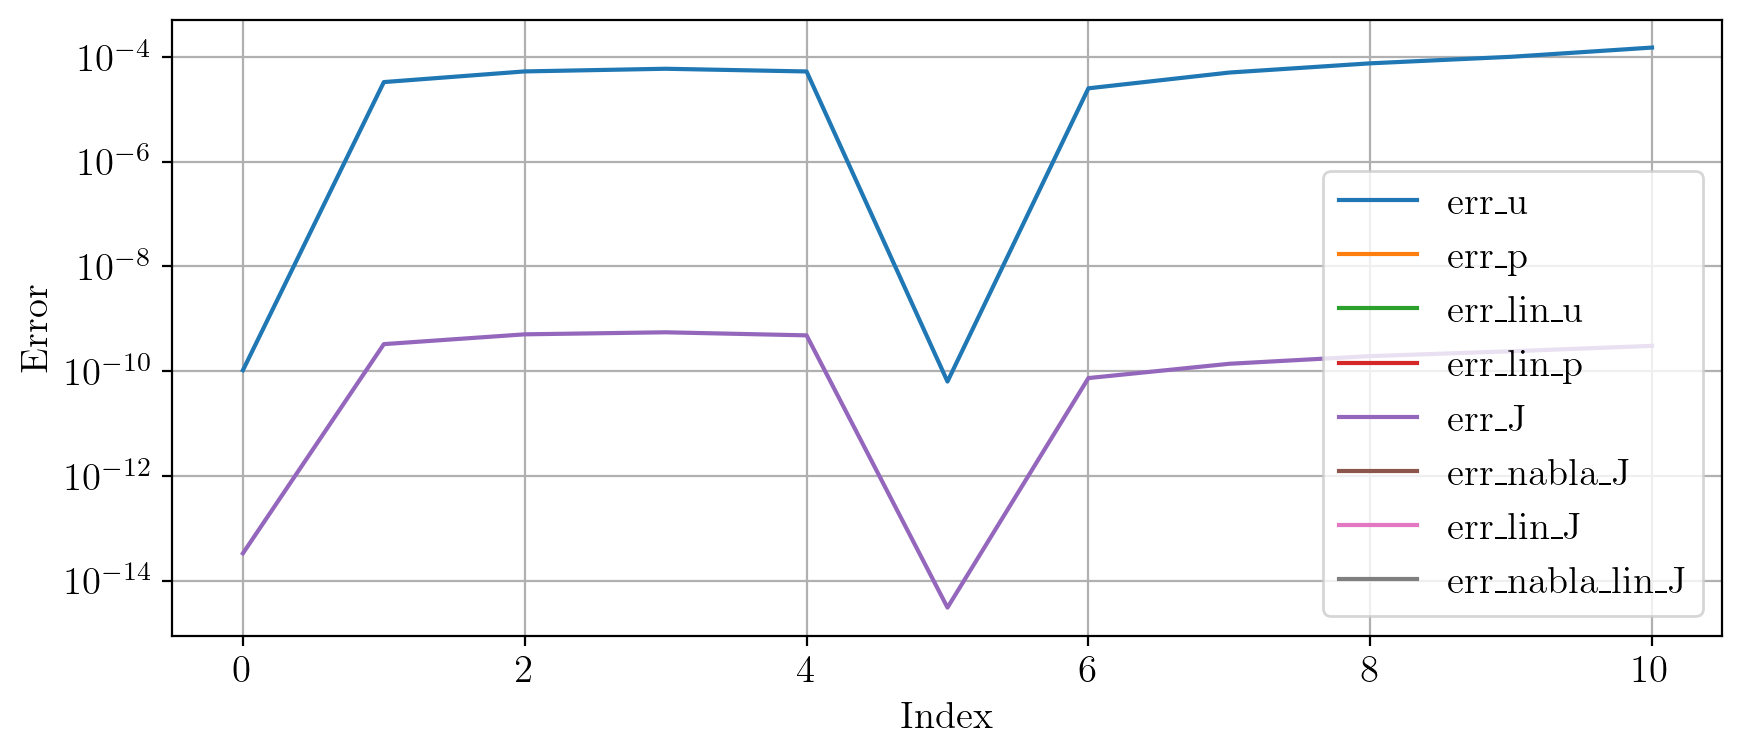

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

# for i in range(len(q_test) + 1):
#     if i % res_q == 0:
#         ax.axvline(i, color='red', linewidth=1)

# Optional: show something plotted for context
for key in errors.keys():
    if not key.startswith("rel_"):
        plt.plot(np.array(errors[key]), label = key)

ax.set_xlabel("Index")
ax.set_ylabel("Error")
ax.grid(True)
ax.set_yscale('log')
ax.legend()

plt.show()